# ЛР5

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
%matplotlib inline

sns.set_theme(style='whitegrid')

orders    = pd.read_csv('olist_orders_dataset.csv', on_bad_lines='skip', encoding='latin-1')
items     = pd.read_csv('olist_order_items_dataset.csv', on_bad_lines='skip', encoding='latin-1')
customers = pd.read_csv('olist_customers_dataset.csv', on_bad_lines='skip',
                         encoding='latin-1', dtype={'customer_zip_code_prefix': str})
reviews   = pd.read_csv('olist_order_reviews_dataset.csv', on_bad_lines='skip', encoding='latin-1')

print('orders:   ', orders.shape)
print('items:    ', items.shape)
print('customers:', customers.shape)
print('reviews:  ', reviews.shape)

orders:    (192964, 8)
items:     (217684, 7)
customers: (187335, 5)
reviews:   (162502, 7)


/tmp/ipykernel_2104/4016199539.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews   = pd.read_csv('olist_order_reviews_dataset.csv', on_bad_lines='skip', encoding='latin-1')


даты, срок доставки в рабочих днях и признак просрочки из ЛР4.

In [3]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

mask = orders['order_approved_at'].notna() & orders['order_delivered_customer_date'].notna()
approved  = orders.loc[mask, 'order_approved_at'].values.astype('datetime64[D]')
delivered = orders.loc[mask, 'order_delivered_customer_date'].values.astype('datetime64[D]')
orders['delivery_time_working_days'] = np.nan
orders.loc[mask, 'delivery_time_working_days'] = np.busday_count(approved, delivered)

orders['is_delayed'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']

print('Срок доставки (раб. дни), медиана:', orders['delivery_time_working_days'].median())
print('Доля просроченных доставок: {:.1%}'.format(
    orders.dropna(subset=['order_delivered_customer_date'])['is_delayed'].mean()))

Срок доставки (раб. дни), медиана: 7.0
Доля просроченных доставок: 8.1%


дневная выручка, скользящие 30-дневные μ/σ и аномалии Z-score > 3 из ЛР4.

In [4]:
items_dated = items.merge(orders[['order_id', 'order_purchase_timestamp']],
                          on='order_id', how='left')
daily = items_dated.groupby(items_dated['order_purchase_timestamp'].dt.normalize())['price'].sum()
daily.index.name = 'date'

full = daily.reindex(pd.date_range(daily.index.min(), daily.index.max(), freq='D')).fillna(0)

revenue = full['2017-01-01':'2018-08-22']
ts = revenue.to_frame('revenue')

ts['roll_mean_30'] = ts['revenue'].rolling(window=30).mean()
ts['roll_std_30']  = ts['revenue'].rolling(window=30).std()
ts['z_score'] = (ts['revenue'] - ts['roll_mean_30']) / ts['roll_std_30']

anomalies = ts[ts['z_score'] > 3]
print('Аномальных дней (Z > 3):', len(anomalies))
anomalies[['revenue', 'z_score']].round(2)

Аномальных дней (Z > 3): 4


,revenue,z_score
2017-08-29,123349.44,3.12
2017-11-20,163402.40,4.04
2017-11-23,171688.05,3.13
2017-11-24,575073.62,5.09


Матрица активности из ЛР4

In [5]:
orders['weekday'] = orders['order_purchase_timestamp'].dt.day_name()
orders['hour'] = orders['order_purchase_timestamp'].dt.hour

week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
intraday = orders.pivot_table(index='weekday', columns='hour',
                              values='order_id', aggfunc='count').reindex(week_order)
intraday.iloc[:, :6]

hour,0.0,1.0,2.0,3.0,4.0,5.0
weekday,,,,,,
Monday,637,258,127,71,42,42
Tuesday,590,306,155,56,57,47
Wednesday,773,343,155,65,60,53
Thursday,694,328,146,76,60,53
Friday,826,421,141,96,77,64
Saturday,610,340,130,81,50,48
Sunday,522,277,132,82,54,54


когортная матрица удержания из ЛР3

In [6]:
om = orders.merge(customers[['customer_id', 'customer_unique_id', 'customer_state']],
                  on='customer_id', how='left')
om['order_month'] = om['order_purchase_timestamp'].dt.to_period('M')

first_month = om.groupby('customer_unique_id')['order_purchase_timestamp'].min().dt.to_period('M')
om['cohort'] = om['customer_unique_id'].map(first_month)

om['offset'] = ((om['order_month'].dt.year  - om['cohort'].dt.year) * 12 +
                (om['order_month'].dt.month - om['cohort'].dt.month))

cohort_counts = (om.groupby(['cohort', 'offset'])['customer_unique_id']
                   .nunique().reset_index()
                   .pivot(index='cohort', columns='offset', values='customer_unique_id'))

retention = cohort_counts.divide(cohort_counts[0], axis=0) * 100

retention = retention.loc['2017-01':'2018-06', 0:6]
retention.round(2)

offset,0,1,2,3,4,5,6
cohort,,,,,,,
2017-01,100.0,0.39,0.26,0.13,0.39,0.13,0.52
2017-02,100.0,0.23,0.29,0.11,0.40,0.11,0.23
2017-03,100.0,0.49,0.38,0.38,0.34,0.15,0.15
2017-04,100.0,0.60,0.21,0.17,0.34,0.26,0.34
2017-05,100.0,0.50,0.50,0.39,0.31,0.33,0.42
2017-06,100.0,0.48,0.35,0.41,0.25,0.38,0.38
2017-07,100.0,0.51,0.36,0.26,0.28,0.21,0.31
2017-08,100.0,0.69,0.33,0.26,0.36,0.53,0.29
2017-09,100.0,0.68,0.53,0.29,0.46,0.22,0.22



### 1.1 Hexbin и KDE связь цены и стоимости доставки

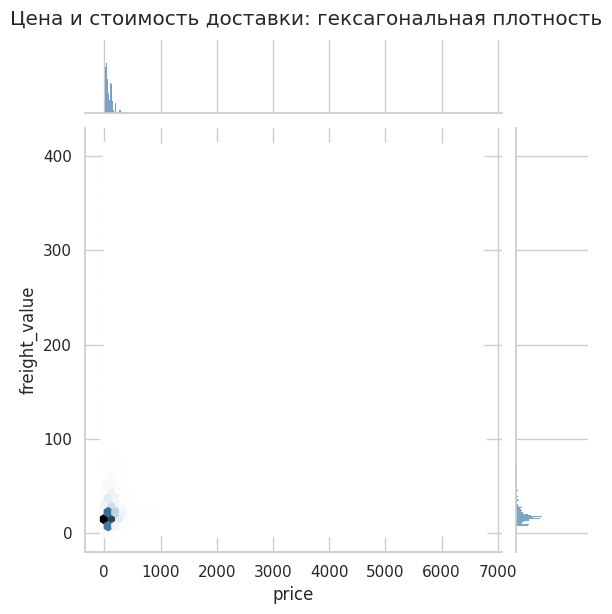

In [7]:
g = sns.jointplot(data=items, x='price', y='freight_value', kind='hex',
                  height=6, color='steelblue')
g.figure.suptitle('Цена и стоимость доставки: гексагональная плотность', y=1.02)
plt.show()

### 1.2 логарифмирование

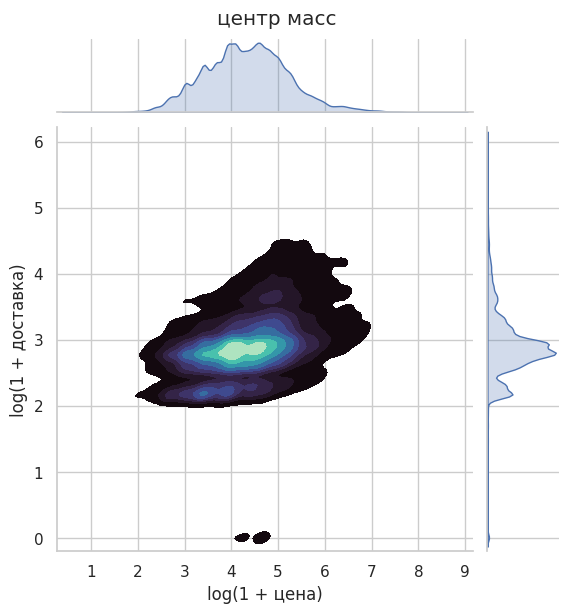

In [8]:
items_log = pd.DataFrame({
    'log_price':   np.log1p(items['price']),
    'log_freight': np.log1p(items['freight_value'])
})

g = sns.jointplot(data=items_log, x='log_price', y='log_freight', kind='kde',
                  height=6, fill=True, cmap='mako')
g.set_axis_labels('log(1 + цена)', 'log(1 + доставка)')
g.figure.suptitle('центр масс', y=1.02)
plt.show()

### 1.3 boxenplot форма хвостов срока доставки по топ-5 штатам


Топ-5 штатов: ['SP', 'RJ', 'MG', 'RS', 'PR']


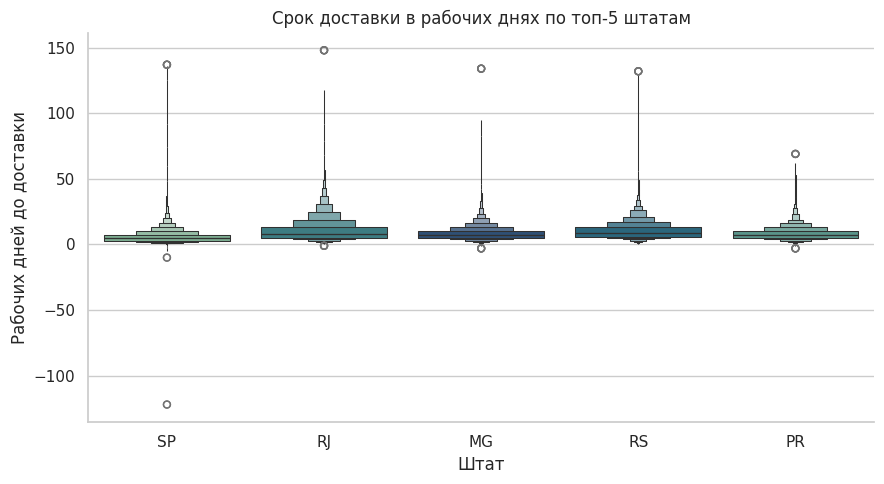

In [9]:
top5_states = om['customer_state'].value_counts().head(5).index.tolist()
print('Топ-5 штатов:', top5_states)

sub = om[om['customer_state'].isin(top5_states)].dropna(subset=['delivery_time_working_days'])

plt.figure(figsize=(9, 5))
sns.boxenplot(data=sub, x='customer_state', y='delivery_time_working_days',
              order=top5_states, hue='customer_state', palette='crest', legend=False)
plt.title('Срок доставки в рабочих днях по топ-5 штатам')
plt.xlabel('Штат')
plt.ylabel('Рабочих дней до доставки')
sns.despine()
plt.tight_layout()
plt.show()


### 2.1 тепловая карта удержания

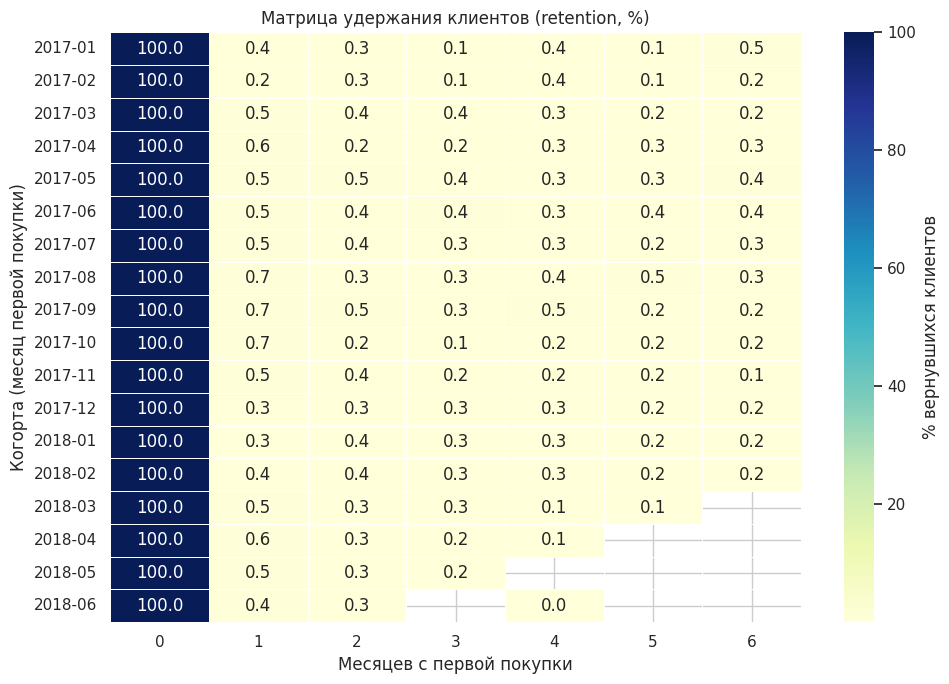

In [10]:
plt.figure(figsize=(10, 7))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': '% вернувшихся клиентов'})
plt.title('Матрица удержания клиентов (retention, %)')
plt.xlabel('Месяцев с первой покупки')
plt.ylabel('Когорта (месяц первой покупки)')
plt.tight_layout()
plt.show()

### 2.2 активность день недели х час

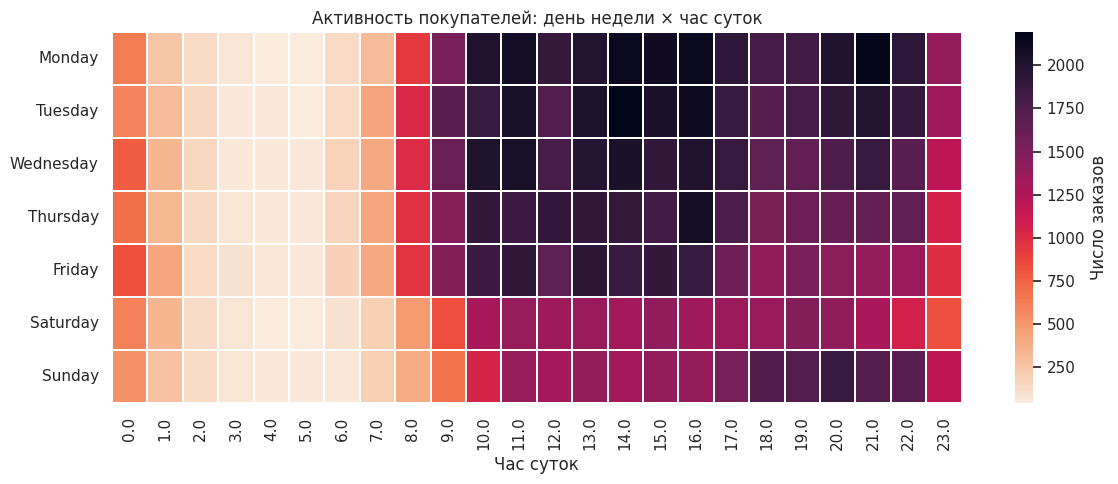

In [11]:
plt.figure(figsize=(12, 5))
sns.heatmap(intraday, cmap='rocket_r', linewidths=0.3,
            cbar_kws={'label': 'Число заказов'})
plt.title('Активность покупателей: день недели × час суток')
plt.xlabel('Час суток')
plt.ylabel('')
plt.tight_layout()
plt.show()

##3. временной ряд с подсветкой аномалий


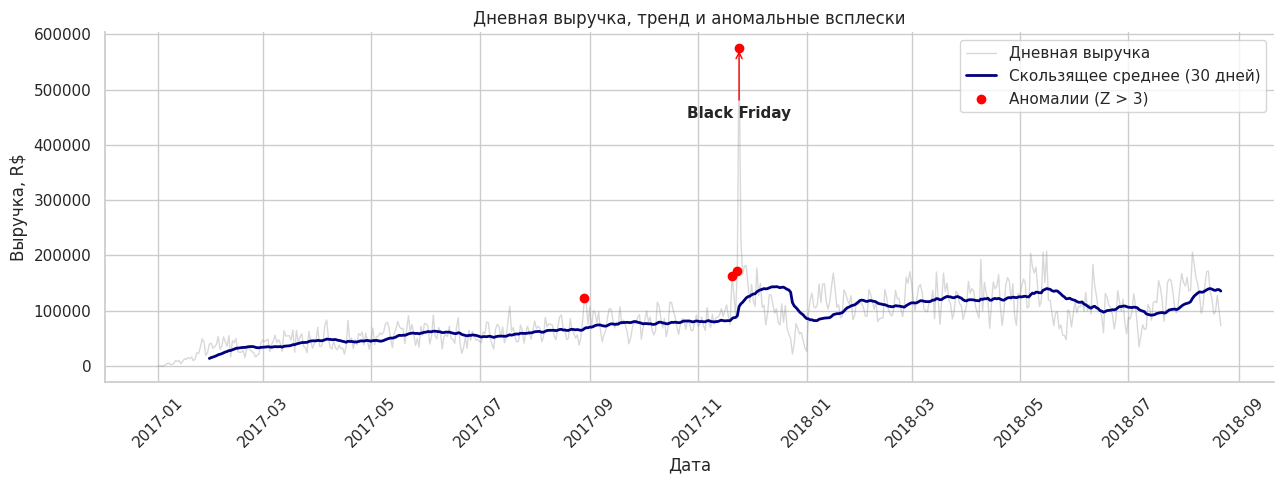

In [12]:
plt.figure(figsize=(13, 5))

plt.plot(ts.index, ts['revenue'], color='gray', alpha=0.3, linewidth=1,
         label='Дневная выручка')

plt.plot(ts.index, ts['roll_mean_30'], color='navy', linewidth=2,
         label='Скользящее среднее (30 дней)')

plt.scatter(anomalies.index, anomalies['revenue'], color='red', zorder=5,
            label='Аномалии (Z > 3)')

bf = anomalies['revenue'].idxmax()
plt.annotate('Black Friday', xy=(bf, anomalies['revenue'].max()),
             xytext=(bf, anomalies['revenue'].max() * 0.78),
             ha='center', fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Дневная выручка, тренд и аномальные всплески')
plt.xlabel('Дата')
plt.ylabel('Выручка, R$')
plt.xticks(rotation=45)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 4. анализ негтивного опыта ассиметричный дашборд

In [14]:
rev1 = reviews.drop_duplicates('order_id')[['order_id', 'review_score']].copy()
rev1['review_score'] = pd.to_numeric(rev1['review_score'], errors='coerce')

deliv = orders.dropna(subset=['order_delivered_customer_date']).merge(rev1, on='order_id', how='left')
sla_score = deliv.dropna(subset=['review_score']).copy()
sla_score['Доставка'] = sla_score['is_delayed'].map({False: 'Вовремя', True: 'Просрочено'})

items_rev = items.merge(rev1, on='order_id', how='left').dropna(subset=['review_score'])
items_rev['review_score'] = items_rev['review_score'].astype(int)

print('Средняя оценка по факту просрочки:')
print(sla_score.groupby('Доставка')['review_score'].mean().round(2))

Средняя оценка по факту просрочки:
Доставка
Вовремя       4.29
Просрочено    2.56
Name: review_score, dtype: float64


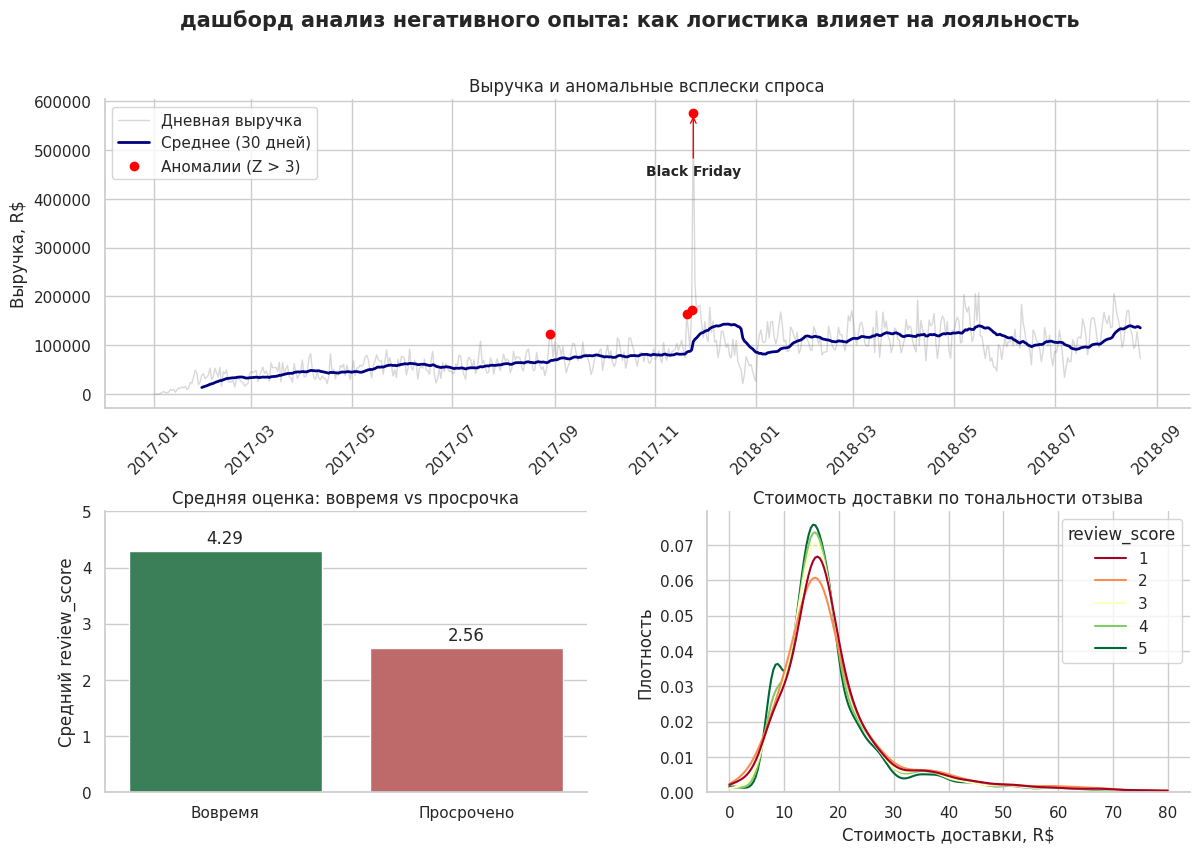

In [15]:
fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1.1, 1], hspace=0.35, wspace=0.25)

ax_top = fig.add_subplot(gs[0, :])
ax_bl  = fig.add_subplot(gs[1, 0])
ax_br  = fig.add_subplot(gs[1, 1])

ax_top.plot(ts.index, ts['revenue'], color='gray', alpha=0.3, linewidth=1,
            label='Дневная выручка')
ax_top.plot(ts.index, ts['roll_mean_30'], color='navy', linewidth=2,
            label='Среднее (30 дней)')
ax_top.scatter(anomalies.index, anomalies['revenue'], color='red', zorder=5,
               label='Аномалии (Z > 3)')
ax_top.annotate('Black Friday', xy=(bf, anomalies['revenue'].max()),
                xytext=(bf, anomalies['revenue'].max() * 0.78), ha='center',
                fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red'))
ax_top.set_title('Выручка и аномальные всплески спроса')
ax_top.set_ylabel('Выручка, R$')
ax_top.tick_params(axis='x', rotation=45)
ax_top.legend(loc='upper left')

sns.barplot(data=sla_score, x='Доставка', y='review_score',
            order=['Вовремя', 'Просрочено'], hue='Доставка',
            palette={'Вовремя': 'seagreen', 'Просрочено': 'indianred'},
            legend=False, errorbar=None, ax=ax_bl)
ax_bl.set_title('Средняя оценка: вовремя vs просрочка')
ax_bl.set_xlabel('')
ax_bl.set_ylabel('Средний review_score')
ax_bl.set_ylim(0, 5)
for c in ax_bl.containers:
    ax_bl.bar_label(c, fmt='%.2f', padding=3)

sns.kdeplot(data=items_rev, x='freight_value', hue='review_score',
            palette='RdYlGn', common_norm=False, fill=False,
            clip=(0, 80), ax=ax_br)
ax_br.set_title('Стоимость доставки по тональности отзыва')
ax_br.set_xlabel('Стоимость доставки, R$')
ax_br.set_ylabel('Плотность')

sns.despine(fig)
fig.suptitle('дашборд анализ негативного опыта: как логистика влияет на лояльность',
             fontsize=15, fontweight='bold')
plt.show()